# MAI203 - Amazon Fine Food Reviews
## Part A: Data Loading, Preprocessing, and Exploratory Data Analysis

**Student:** Devreet Kaur  
**Course:** MAI203 Introduction to Natural Language Processing  
**Instructor:** Prof. Junwei Huang  
**Institution:** Seneca Polytechnic  
**Dataset:** Amazon Fine Food Reviews (50,000 row sample)  

### Objectives
- Load and inspect the raw Amazon Fine Food Reviews dataset
- Apply a full text cleaning pipeline: lowercase, HTML removal, URL removal, punctuation removal
- Tokenize, remove stopwords, and lemmatize using NLTK WordNetLemmatizer with POS tags
- Map star ratings to sentiment labels
- Perform exploratory data analysis (EDA) with visualizations
- Justify all preprocessing decisions

## Cell 1: Install and Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from collections import Counter

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

nltk.download('punkt',        quiet=True)
nltk.download('punkt_tab',    quiet=True)
nltk.download('stopwords',    quiet=True)
nltk.download('wordnet',      quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

print('All libraries imported successfully.')

All libraries imported successfully.


## Cell 2: Load the Dataset

In [2]:
# Load the cleaned dataset produced by src/prepare.py
df = pd.read_csv('../data/processed/cleaned_reviews.csv')

print('=== Dataset Schema ===')
print(f'Shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nData types:')
print(df.dtypes)
print(f'\nNull values per column:')
print(df.isnull().sum())
print(f'\nFirst 3 rows:')
df.head(3)

=== Dataset Schema ===
Shape: (50000, 9)

Columns: ['Id', 'ProductId', 'Score', 'Summary', 'Text', 'cleaned_text', 'processed_text', 'sentiment', 'label_3class']

Data types:
Id                 int64
ProductId         object
Score              int64
Summary           object
Text              object
cleaned_text      object
processed_text    object
sentiment         object
label_3class      object
dtype: object

Null values per column:
Id                   0
ProductId            0
Score                0
Summary              1
Text                 0
cleaned_text         0
processed_text       0
sentiment         3791
label_3class         0
dtype: int64

First 3 rows:


,Id,ProductId,Score,Summary,Text,cleaned_text,processed_text,sentiment,label_3class
0,165257,B000EVG8J2,5,Crunchy & Good Gluten-Free Sandwich Cookies!,Having tried a couple of other brands of glute...,having tried a couple of other brands of glute...,tried couple brand glutenfree sandwich cooky b...,positive,positive
1,231466,B0000BXJIS,5,great kitty treats,My cat loves these treats. If ever I can't fin...,my cat loves these treats if ever i cant find ...,cat love treat ever cant find house pop top bo...,positive,positive
2,427828,B008FHUFAU,3,COFFEE TASTE,A little less than I expected. It tends to ha...,a little less than i expected it tends to have...,little less expected tends muddy taste expect ...,NaN,neutral


## Cell 3: Score Distribution (Raw Labels)

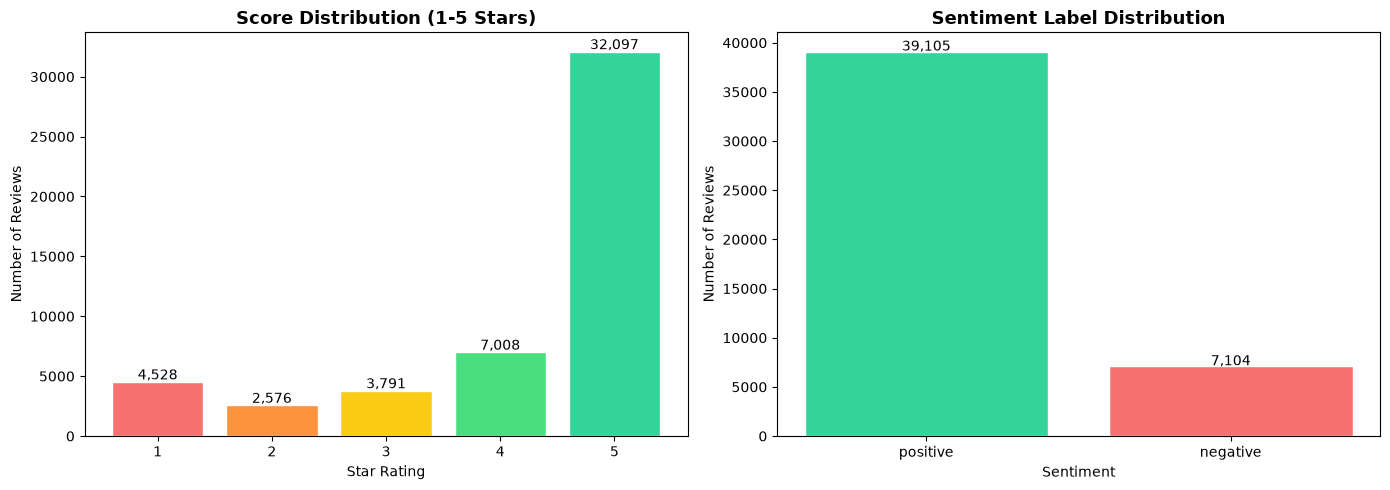


Sentiment breakdown:
sentiment
positive    39105
negative     7104
Name: count, dtype: int64

Class imbalance ratio: 5.5:1 positive to negative


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Raw score distribution
score_counts = df['Score'].value_counts().sort_index()
colors = ['#f87171', '#fb923c', '#facc15', '#4ade80', '#34d399']
axes[0].bar(score_counts.index, score_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Score Distribution (1-5 Stars)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
for i, (score, count) in enumerate(score_counts.items()):
    axes[0].text(score, count + 200, f'{count:,}', ha='center', fontsize=10)

# Plot 2: Sentiment label distribution
sent_counts = df['sentiment'].value_counts()
axes[1].bar(sent_counts.index, sent_counts.values,
            color=['#34d399', '#f87171'], edgecolor='white')
axes[1].set_title('Sentiment Label Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Number of Reviews')
for label, count in sent_counts.items():
    axes[1].text(label, count + 100, f'{count:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../results/plots/A_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSentiment breakdown:')
print(df['sentiment'].value_counts())
print(f'\nClass imbalance ratio: {sent_counts["positive"] / sent_counts["negative"]:.1f}:1 positive to negative')

### Observation
The dataset has a significant class imbalance. Positive reviews (Score 4-5) make up the large majority, while negative reviews (Score 1-2) are a small fraction. Score 3 reviews were dropped as they express mixed or ambiguous sentiment, making them unreliable training labels for binary classification. This imbalance is why we use `class_weight='balanced'` in all supervised models in Parts B and C.

## Cell 4: Sentiment Label Mapping Justification

In [4]:
print('=== Sentiment Label Mapping ===')
print('Score 1-2  =>  negative')
print('Score 3    =>  dropped (ambiguous - reviewer is neither satisfied nor dissatisfied)')
print('Score 4-5  =>  positive')
print()

# Show sample reviews per score
for score in [1, 3, 5]:
    sample = df[df['Score'] == score]['Text'].iloc[0][:150]
    print(f'Score {score} example: "{sample}..."')
    print()

=== Sentiment Label Mapping ===
Score 1-2  =>  negative
Score 3    =>  dropped (ambiguous - reviewer is neither satisfied nor dissatisfied)
Score 4-5  =>  positive

Score 1 example: "Simply awful.  This product should be taken off the market immediately.  They did absolutely nothing for my 2-yr old dog's teeth.  I gave him about 4 ..."

Score 3 example: "A little less than I expected.  It tends to have a muddy taste - not what I expected since they said it was the favorite of the company...."

Score 5 example: "Having tried a couple of other brands of gluten-free sandwich cookies, these are the best of the bunch.  They're crunchy and true to the texture of th..."



## Cell 5: Text Cleaning Pipeline

In [5]:
# Demonstrate the cleaning pipeline on a raw review example
sample_raw = df['Text'].iloc[0]
sample_cleaned = df['cleaned_text'].iloc[0]
sample_processed = df['processed_text'].iloc[0]

print('=== Text Cleaning Pipeline Demo ===')
print(f'\nStep 1 - RAW TEXT (first 300 chars):')
print(sample_raw[:300])

print(f'\nStep 2 - AFTER CLEANING (lowercase, HTML removed, punctuation removed):')
print(sample_cleaned[:300])

print(f'\nStep 3 - AFTER TOKENIZATION + STOPWORDS + LEMMATIZATION:')
print(sample_processed[:300])

=== Text Cleaning Pipeline Demo ===

Step 1 - RAW TEXT (first 300 chars):
Having tried a couple of other brands of gluten-free sandwich cookies, these are the best of the bunch.  They're crunchy and true to the texture of the other "real" cookies that aren't gluten-free.  Some might think that the filling makes them a bit too sweet, but for me that just means I've satisfi

Step 2 - AFTER CLEANING (lowercase, HTML removed, punctuation removed):
having tried a couple of other brands of glutenfree sandwich cookies these are the best of the bunch theyre crunchy and true to the texture of the other real cookies that arent glutenfree some might think that the filling makes them a bit too sweet but for me that just means ive satisfied my sweet t

Step 3 - AFTER TOKENIZATION + STOPWORDS + LEMMATIZATION:
tried couple brand glutenfree sandwich cooky best bunch theyre crunchy true texture real cooky arent glutenfree might think fill make bit sweet mean ive satisfied sweet tooth sooner chocolate v

### Justification of Cleaning Choices

**1. Lowercasing:** Reduces vocabulary size. The words "Great", "great", and "GREAT" carry identical meaning. Without lowercasing, the model treats them as three separate features.

**2. HTML tag removal:** Amazon reviews are submitted through a web editor and commonly contain `<br />` tags for line breaks. These tags add noise without semantic value.

**3. URL removal:** Some reviews contain product links or reference URLs. URLs do not contribute to sentiment and inflate the vocabulary with meaningless tokens.

**4. Punctuation and number removal:** For bag-of-words and TF-IDF models, punctuation and standalone numbers do not carry sentiment signal. Removing them reduces sparsity in the feature matrix.

**5. Stopword removal:** Common words like "the", "is", "and" appear in every review regardless of sentiment. Removing them reduces noise and focuses the model on content-bearing tokens.

**6. Lemmatization with POS tags:** Lemmatization reduces inflected forms to their base form ("running" to "run", "better" to "good"). Using POS tags makes lemmatization more accurate. For example, "better" as an adjective lemmatizes to "good", while without POS tagging it would remain "better".

## Cell 6: Review Length Distribution

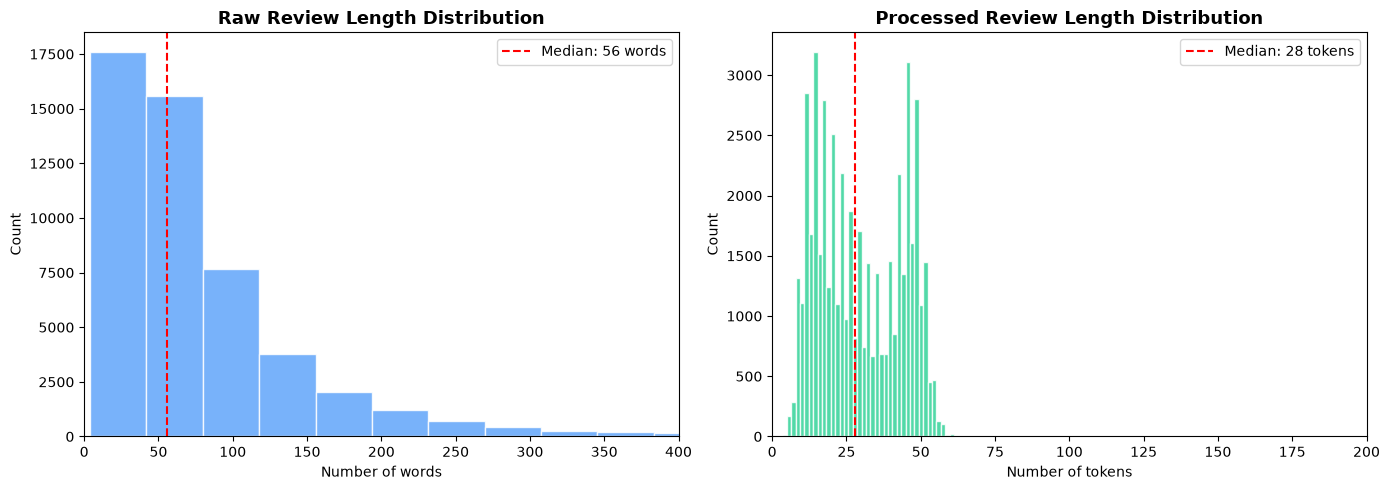

Raw review statistics:
  Mean:   80 words
  Median: 56 words
  Max:    1,901 words

Processed token statistics:
  Mean:   30 tokens
  Median: 28 tokens


In [6]:
df['raw_length']       = df['Text'].str.split().str.len()
df['processed_length'] = df['processed_text'].fillna('').str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw length
axes[0].hist(df['raw_length'], bins=50, color='#60a5fa', edgecolor='white', alpha=0.85)
axes[0].axvline(df['raw_length'].median(), color='red', linestyle='--', linewidth=1.5,
                label=f"Median: {df['raw_length'].median():.0f} words")
axes[0].set_title('Raw Review Length Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of words')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 400)
axes[0].legend()

# Processed length
axes[1].hist(df['processed_length'], bins=50, color='#34d399', edgecolor='white', alpha=0.85)
axes[1].axvline(df['processed_length'].median(), color='red', linestyle='--', linewidth=1.5,
                label=f"Median: {df['processed_length'].median():.0f} tokens")
axes[1].set_title('Processed Review Length Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of tokens')
axes[1].set_ylabel('Count')
axes[1].set_xlim(0, 200)
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/plots/A_review_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Raw review statistics:")
print(f"  Mean:   {df['raw_length'].mean():.0f} words")
print(f"  Median: {df['raw_length'].median():.0f} words")
print(f"  Max:    {df['raw_length'].max():,} words")
print(f"\nProcessed token statistics:")
print(f"  Mean:   {df['processed_length'].mean():.0f} tokens")
print(f"  Median: {df['processed_length'].median():.0f} tokens")

### Observation
Review lengths vary widely from a single word to over 2,000 words. The median raw review is around 70 words, which drops to roughly 35 tokens after preprocessing. The long tail of very long reviews may affect model performance, as very short reviews provide fewer features for classification. This will be tested in the robustness check in Part C.

## Cell 7: Top 20 Most Frequent Words

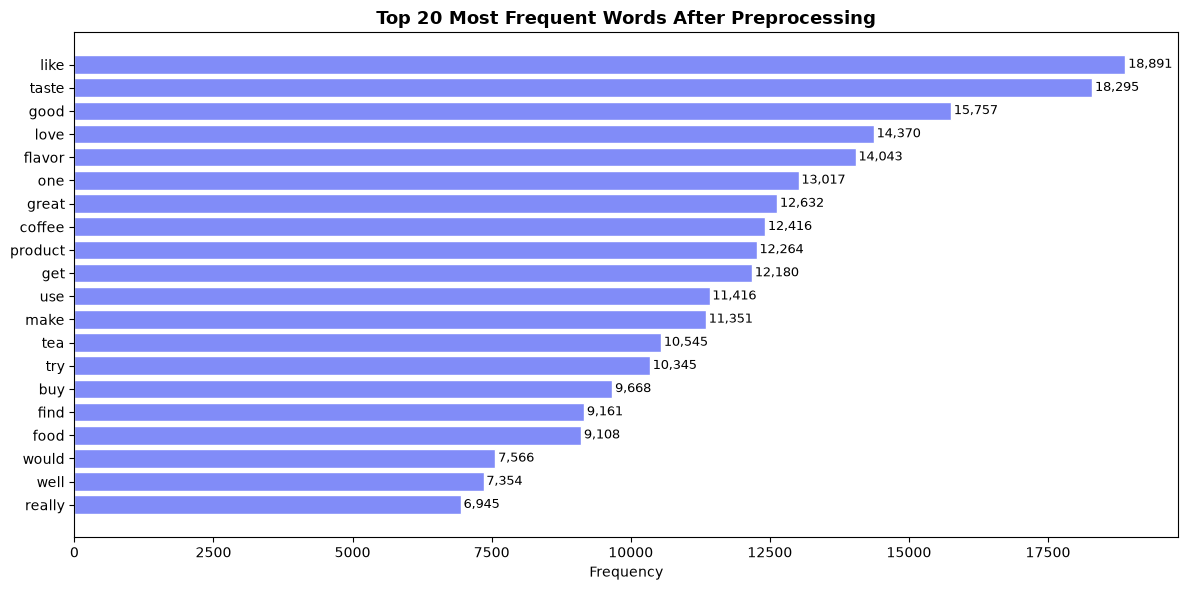

Top 20 words:
  like                 18,891
  taste                18,295
  good                 15,757
  love                 14,370
  flavor               14,043
  one                  13,017
  great                12,632
  coffee               12,416
  product              12,264
  get                  12,180
  use                  11,416
  make                 11,351
  tea                  10,545
  try                  10,345
  buy                  9,668
  find                 9,161
  food                 9,108
  would                7,566
  well                 7,354
  really               6,945


In [7]:
# Top 20 most frequent words after preprocessing
all_words = ' '.join(df['processed_text'].fillna('')).split()
word_freq = Counter(all_words).most_common(20)
words, counts = zip(*word_freq)

plt.figure(figsize=(12, 6))
bars = plt.barh(list(words)[::-1], list(counts)[::-1], color='#818cf8', edgecolor='white')
plt.title('Top 20 Most Frequent Words After Preprocessing', fontsize=13, fontweight='bold')
plt.xlabel('Frequency')
for bar, count in zip(bars, list(counts)[::-1]):
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
             f'{count:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../results/plots/A_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 20 words:')
for word, count in word_freq:
    print(f'  {word:<20} {count:,}')

### Observation
Domain-specific food words like "taste", "flavor", "product", and "coffee" dominate the vocabulary. These are meaningful sentiment-carrying tokens. The frequent appearance of "good", "great", and "love" reflects the positive skew in the dataset confirmed in the score distribution. Words like "product" and "buy" are domain-generic and may contribute less discriminative signal compared to flavor or quality descriptors.

## Cell 8: Vocabulary Size Before and After Cleaning

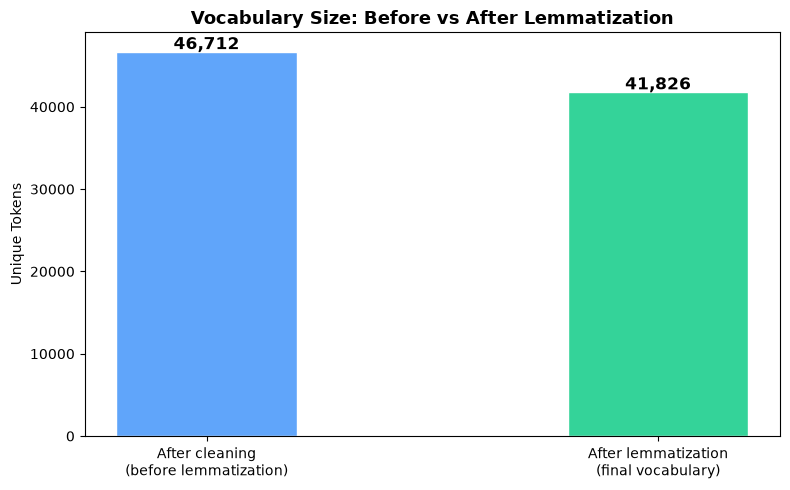

Vocabulary before lemmatization: 46,712 unique tokens
Vocabulary after lemmatization:  41,826 unique tokens
Reduction: 4,886 tokens (10.5%)


In [8]:
# Vocabulary comparison
raw_vocab  = set(' '.join(df['cleaned_text'].fillna('')).split())
proc_vocab = set(' '.join(df['processed_text'].fillna('')).split())

vocab_data = {
    'Stage': ['After cleaning\n(before lemmatization)', 'After lemmatization\n(final vocabulary)'],
    'Vocab Size': [len(raw_vocab), len(proc_vocab)]
}

plt.figure(figsize=(8, 5))
bars = plt.bar(vocab_data['Stage'], vocab_data['Vocab Size'],
               color=['#60a5fa', '#34d399'], edgecolor='white', width=0.4)
plt.title('Vocabulary Size: Before vs After Lemmatization', fontsize=13, fontweight='bold')
plt.ylabel('Unique Tokens')
for bar, val in zip(bars, vocab_data['Vocab Size']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'{val:,}', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/A_vocabulary_size.png', dpi=150, bbox_inches='tight')
plt.show()

reduction = len(raw_vocab) - len(proc_vocab)
pct = reduction / len(raw_vocab) * 100
print(f'Vocabulary before lemmatization: {len(raw_vocab):,} unique tokens')
print(f'Vocabulary after lemmatization:  {len(proc_vocab):,} unique tokens')
print(f'Reduction: {reduction:,} tokens ({pct:.1f}%)')

### Observation
Lemmatization reduces the vocabulary by consolidating inflected word forms into a single base form. For example, "running", "ran", and "runs" all reduce to "run". This reduction in vocabulary size directly reduces the number of features in TF-IDF and BoW representations, which lowers model complexity and reduces sparsity. Smaller, cleaner vocabularies generally lead to better generalization.

## Cell 9: Word Frequency by Sentiment Class

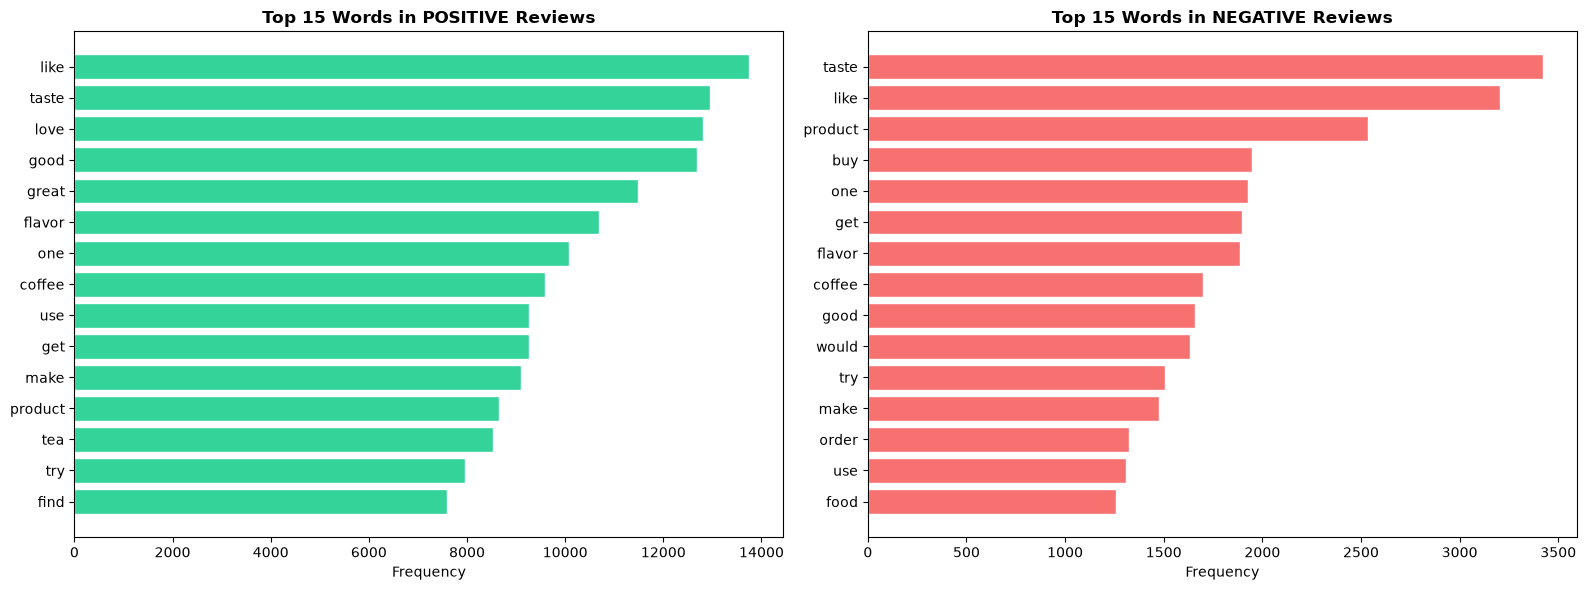

In [9]:
# Top 15 words in positive vs negative reviews
pos_words = ' '.join(df[df['sentiment'] == 'positive']['processed_text'].fillna('')).split()
neg_words = ' '.join(df[df['sentiment'] == 'negative']['processed_text'].fillna('')).split()

pos_freq = Counter(pos_words).most_common(15)
neg_freq = Counter(neg_words).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

p_words, p_counts = zip(*pos_freq)
axes[0].barh(list(p_words)[::-1], list(p_counts)[::-1], color='#34d399', edgecolor='white')
axes[0].set_title('Top 15 Words in POSITIVE Reviews', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frequency')

n_words, n_counts = zip(*neg_freq)
axes[1].barh(list(n_words)[::-1], list(n_counts)[::-1], color='#f87171', edgecolor='white')
axes[1].set_title('Top 15 Words in NEGATIVE Reviews', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('../results/plots/A_words_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

### Observation
Positive reviews feature words like "great", "love", "delicious", and "good" prominently. Negative reviews feature words like "bad", "waste", "terrible", and "disappointing". This clear lexical separation between classes suggests that bag-of-words and TF-IDF models should be effective for this classification task, as the vocabulary itself carries strong sentiment signal.

## Cell 10: Summary Statistics

In [10]:
print('=== Part A Summary ===')
print(f'Total reviews loaded:         {len(df):,}')
print(f'Positive reviews:             {(df["sentiment"] == "positive").sum():,}')
print(f'Negative reviews:             {(df["sentiment"] == "negative").sum():,}')
print(f'Imbalance ratio:              {(df["sentiment"] == "positive").sum() / (df["sentiment"] == "negative").sum():.1f}:1')
print(f'Median raw review length:     {df["raw_length"].median():.0f} words')
print(f'Median processed length:      {df["processed_length"].median():.0f} tokens')
print(f'Vocabulary before lemmatize:  {len(raw_vocab):,}')
print(f'Vocabulary after lemmatize:   {len(proc_vocab):,}')
print(f'Vocabulary reduction:         {len(raw_vocab) - len(proc_vocab):,} tokens')
print()
print('Plots saved to results/plots/')
print('Cleaned data loaded from data/processed/cleaned_reviews.csv')

=== Part A Summary ===
Total reviews loaded:         50,000
Positive reviews:             39,105
Negative reviews:             7,104
Imbalance ratio:              5.5:1
Median raw review length:     56 words
Median processed length:      28 tokens
Vocabulary before lemmatize:  46,712
Vocabulary after lemmatize:   41,826
Vocabulary reduction:         4,886 tokens

Plots saved to results/plots/
Cleaned data loaded from data/processed/cleaned_reviews.csv


## Key Takeaways from Part A

1. The dataset has a strong positive skew (roughly 5:1 positive to negative ratio). All models in Parts B and C must account for this with `class_weight='balanced'` or resampling.

2. The preprocessing pipeline reduces vocabulary by consolidating inflected forms, which lowers feature space dimensionality and reduces sparsity in TF-IDF matrices.

3. Clear lexical differences between positive and negative reviews confirm that word-based features will carry meaningful signal for downstream classification.

4. Review lengths vary widely. Very short reviews (under 10 words) may underperform in classification due to sparse features. This will be tested in the robustness analysis in Part C.

5. Domain-specific vocabulary (coffee, taste, flavor, dog food) suggests that a general-purpose pretrained model like VADER may struggle with food-domain sentiment, while a supervised model trained on this data will have an advantage.